### DSPOT algoritma darbības piemērs

In [50]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")  
sys.path.insert(0, PROJECT_ROOT)

# mainīgie
data_csv = os.path.join(PROJECT_ROOT, "data/raw/A_K_aukstais_udens.csv")

time_column_name = 'timestamp_unix'
value_column_name = 'value'
datetime_column_name = 'ts'


from src.prepare_data import(
    prepare_data,
    preprocess_data,
    day_use_dataset,
)
from src.anomaly_detection_algorithms.dspot import DriftStreamingPeakOverThreshold
from src.visualizations import visualize_dspot


In [51]:
prepared_data = prepare_data(data_csv, time_column_name, value_column_name, datetime_column_name)
preprocessed_data = preprocess_data(prepared_data, time_column_name, value_column_name, datetime_column_name)
days_df = day_use_dataset(preprocessed_data)


In [4]:
import os

def export_dataset_preprocessed(dataset, name, path):
    os.makedirs(path, exist_ok=True)
    file_path = os.path.join(path, f"{name}.csv")
    dataset.to_csv(file_path, index=False)
    return file_path

output_path = os.path.join(PROJECT_ROOT, "data/preprocessed/")

export_dataset_preprocessed(days_df, 'daily_usage_original', output_path)

'd:\\RTU\\3.kurss\\2.sem\\Bakalaura darbs\\Anomaly_detection_water\\Anomaly_detection_Bakalaura_darbs\\data/preprocessed/daily_usage_original.csv'

In [48]:
data = days_df["delta"].to_numpy()
# PARAMETERS 
num_init = 30
depth = 14

threshold = DriftStreamingPeakOverThreshold(
    data=data,
    num_init=num_init,
    depth=depth,
    num_candidates=10,
    risk=1e-3,
    init_level=0.9,
    epsilon=1e-8,
)

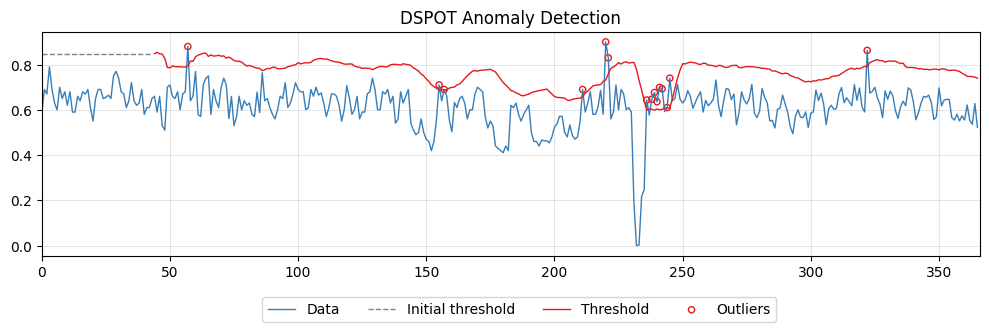

In [49]:
visualize_dspot (
    data = data,
    threshold = threshold,
    num_init = num_init,
    depth = depth,
    title ="DSPOT Anomaly Detection"
)